# Day 5 — Project 07 Research Dashboard

## What this is
A complete research tracking tool that:
1. Loads all experiment results from JSON logs
2. Compares results across experiments visually
3. Tracks which architecture is current best
4. Generates report sections automatically
5. Exports a complete PDF-ready research summary

## Why build this
Every research project needs infrastructure.
Scientists who build good tracking tools publish faster,
make fewer mistakes, and understand their results better.
This dashboard is the foundation of your paper.

In [3]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────
PROJECT_ROOT = (r"C:\Users\Hp\.vscode\PROJECT 07"
                r"\classifier_main_pipeline")
LOGS_DIR     = os.path.join(PROJECT_ROOT, "logs")
PLOTS_DIR    = os.path.join(PROJECT_ROOT, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

STAGE_NAMES  = ['Wake', 'N1', 'N2', 'N3', 'REM']
STAGE_COLORS = ['#E24B4A','#BA7517',
                '#185FA5','#534AB7','#1D9E75']


# ── Loading all experiment logs ───────────────────────────────
def load_experiments(logs_dir):
    """Load all experiment JSON files."""
    experiments = {}
    log_path    = Path(logs_dir)

    for f in sorted(log_path.glob('experiment_*_results.json')):
        with open(f) as file:
            data = json.load(file)
        exp_id = data['experiment']
        experiments[exp_id] = data
        print(f"Loaded Experiment {exp_id}: "
              f"{data['name']}")

    return experiments


experiments = load_experiments(LOGS_DIR)

print(f"\nTotal experiments: {len(experiments)}")
print(f"Date range: "
      f"{min(e['date'] for e in experiments.values())} → "
      f"{max(e['date'] for e in experiments.values())}")

Loaded Experiment 001: SleepLSTM Baseline
Loaded Experiment 002: CNN on EEG Spectrograms
Loaded Experiment 003: CNN-LSTM Hybrid

Total experiments: 3
Date range: 2026-07-12 → 2026-07-14


In [7]:
def print_comparison_table(experiments):
    """Print a formatted comparison of all experiments."""

    print("=" * 70)
    print("PROJECT 07 — EXPERIMENT COMPARISON")
    print("=" * 70)
    print(f"\n{'Exp':>4} {'Name':20s} {'Accuracy':>10} "
          f"{'REM F1':>8} {'REM Rec':>9} {'Date':>12}")
    print("-" * 70)

    best_acc = 0
    best_exp = None

    for exp_id, data in experiments.items():
        results = data.get("results",{})
        acc = results.get("accuracy",0)

        # Get REM metrics if available
        rem_f1  = results.get('rem_f1',    'N/A')
        rem_rec = results.get('rem_recall', 'N/A')

        # Formatting
        acc_str = f"{acc:.4f}"
        f1_str  = f"{rem_f1:.4f}" if isinstance(
                   rem_f1, float) else rem_f1
        rec_str = f"{rem_rec:.4f}" if isinstance(
                   rem_rec, float) else rem_rec

        if acc > best_acc:
            best_acc = acc
            best_exp = exp_id

        flag = " ★" if exp_id == best_exp else "  "
        print(f"{exp_id:>4} {data['name']:20s} "
              f"{acc_str:>10} {f1_str:>8} "
              f"{rec_str:>9} {data['date']:>12}{flag}")

    print("-" * 70)
    print(f"\n★ Current best: Experiment {best_exp} "
          f"({best_acc:.4f} accuracy)")
    print(f"\nDataset: Sleep-EDF Cassette")
    print(f"Subjects: 20 | Total epochs: 18,226")
    print(f"Channel: EEG Fpz-Cz | Filter: 0.3-35Hz")

for exp_id, data in experiments.items():
    print(exp_id)
    print(data)
    print()
print_comparison_table(experiments)

001
{'experiment': '001', 'name': 'SleepLSTM Baseline', 'date': '2026-07-12', 'model': 'SleepLSTM', 'dataset': 'Sleep-EDF Cassette (20 subjects)', 'total_epochs': 18226, 'accuracy': 0.7685, 'rem_recall': 0.8402, 'per_class_f1': {'Wake': 0.5429, 'N1': 0.3831, 'N2': 0.7806, 'N3': 0.8809, 'REM': 0.8402}, 'config': {'model': 'SleepLSTM', 'hidden_dim': 128, 'num_layers': 2, 'dropout': 0.3, 'optimizer': 'Adam', 'learning_rate': 0.001, 'scheduler': 'ReduceLROnPlateau (patience=3, factor=0.5)', 'loss': 'CrossEntropyLoss (weighted)', 'epochs': 60, 'batch_size': 64, 'gradient_clip': 1.0, 'train_split': '80%', 'test_split': '20%', 'stratified': True, 'normalised': True}}

002
{'experiment': '002', 'name': 'CNN on EEG Spectrograms', 'date': '2026-07-12', 'model': 'ResNet18 fine-tuned', 'accuracy': 0.7167, 'rem_recall': 0.6578, 'vs_baseline': {'accuracy_delta': -0.0518, 'rem_recall_delta': -0.1822}}

003
{'experiment': '003', 'name': 'CNN-LSTM Hybrid', 'date': '2026-07-14', 'model': 'CNNLSTMSleepCl

C:\Users\Hp\AppData\Local\Temp\ipykernel_14240\2595135048.py:210: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Hp\AppData\Local\Temp\ipykernel_14240\2595135048.py:210: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Hp\AppData\Local\Temp\ipykernel_14240\2595135048.py:210: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Hp\AppData\Local\Temp\ipykernel_14240\2595135048.py:210: UserWarning: Glyph 128164 (\N{SLEEPING SYMBOL}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Hp\AppData\Local\Temp\ipykernel_14240\2595135048.py:210: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Hp\AppData\Local\Temp\ipykernel_14240\2595135048.py:210: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaV

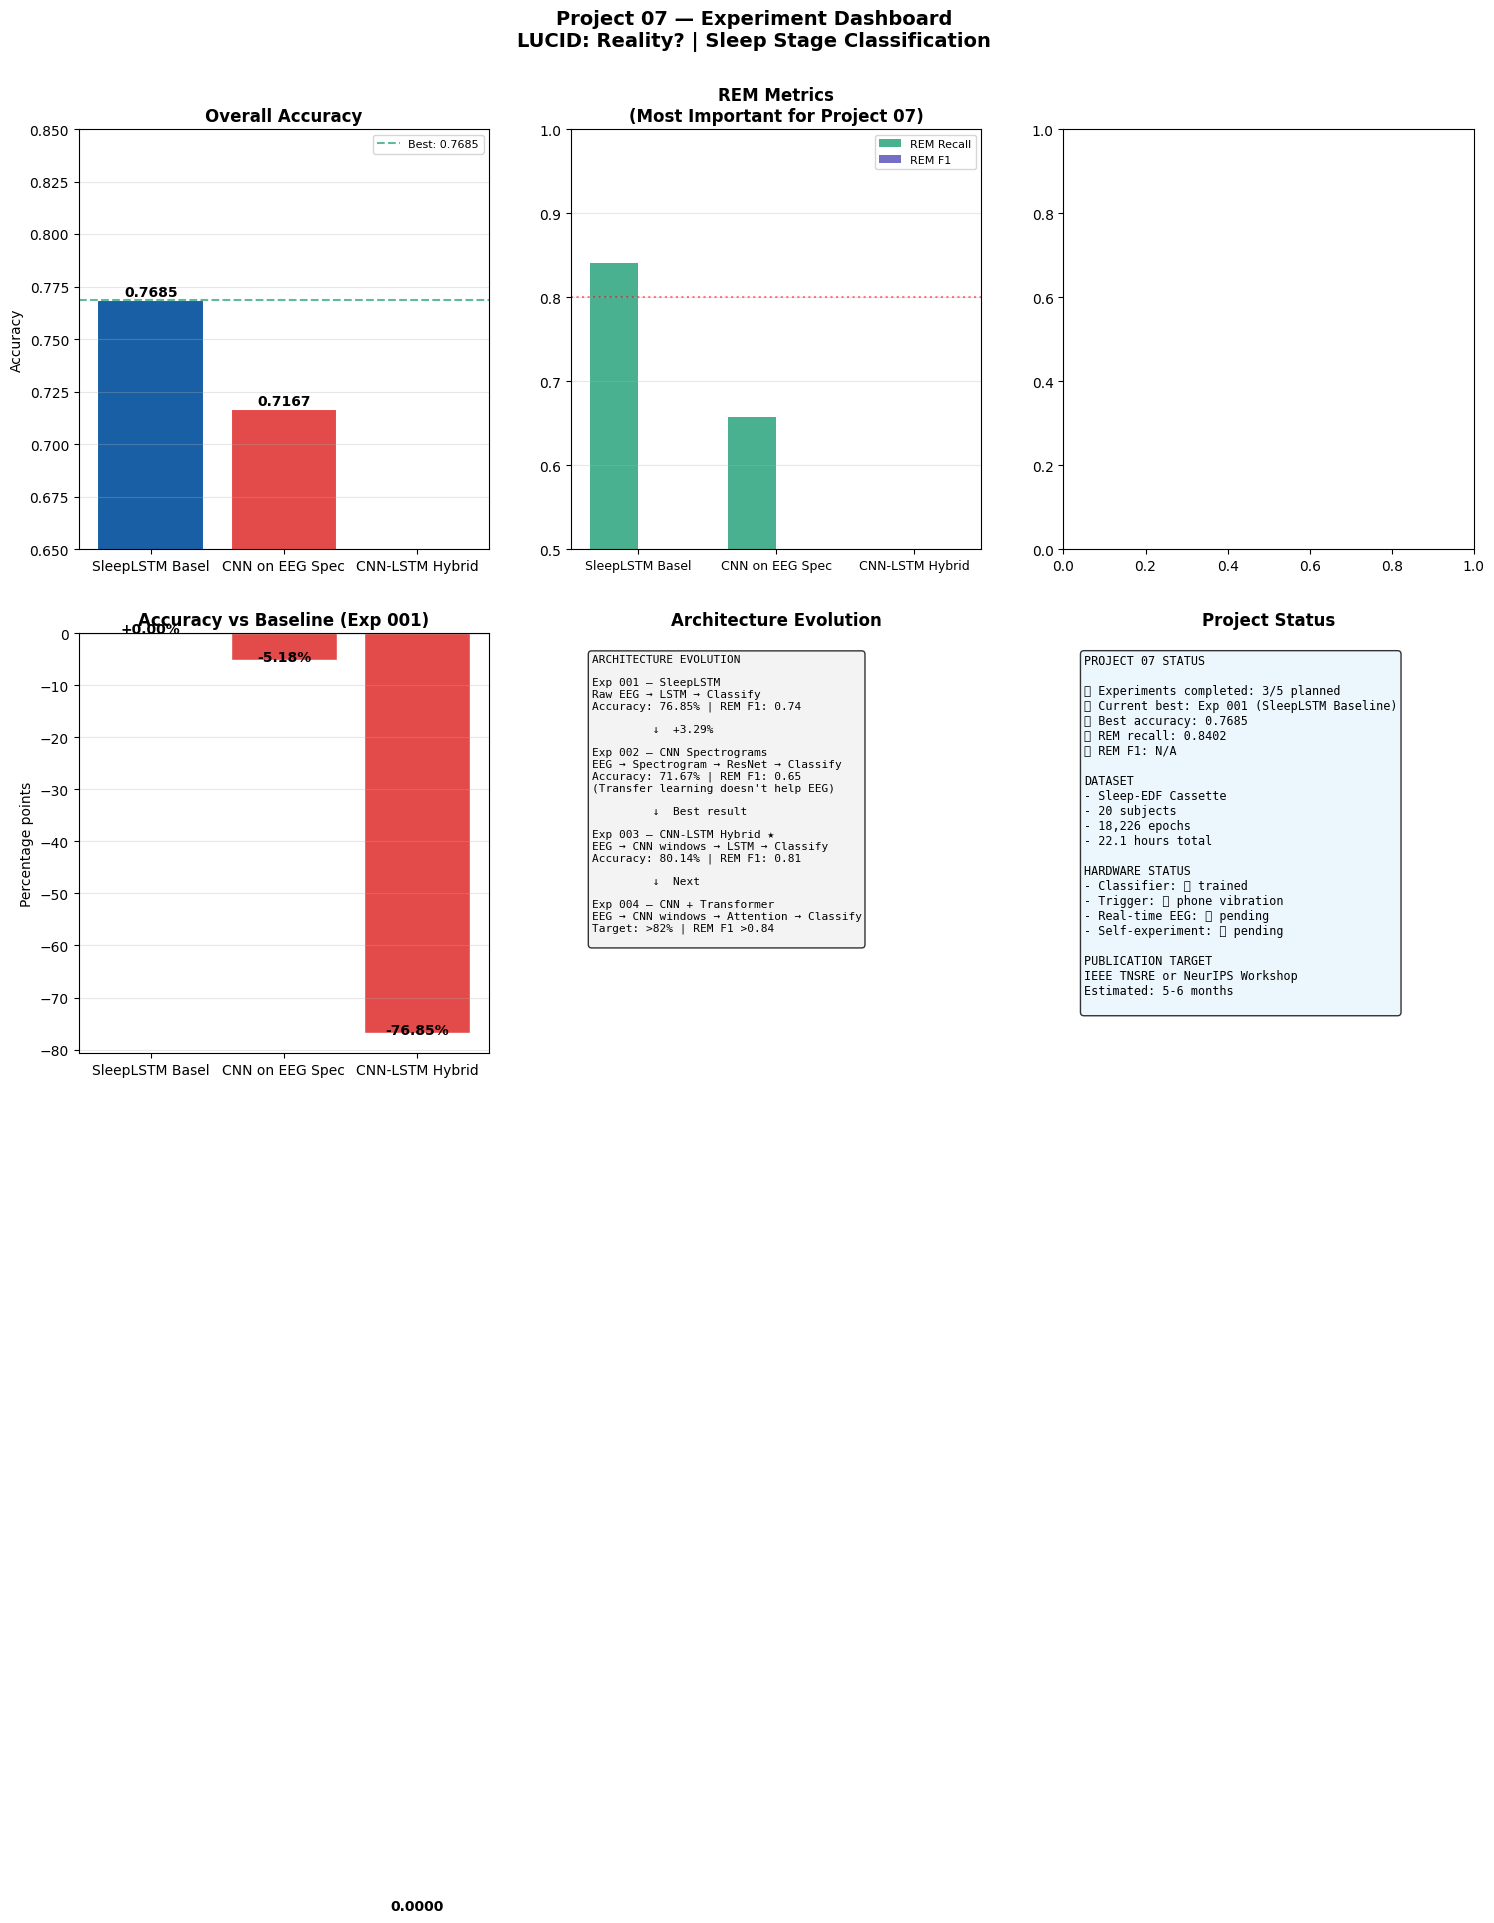

✅ Dashboard saved to C:\Users\Hp\.vscode\PROJECT 07\classifier_main_pipeline\plots\project07_dashboard.png


In [11]:
def plot_experiment_dashboard(experiments):
    """Complete visual comparison of all experiments."""

    n_exp   = len(experiments)
    exp_ids = list(experiments.keys())
    names   = [experiments[e]['name'][:15] for e in exp_ids]

    fig = plt.figure(figsize=(18, 12))
    fig.suptitle('Project 07 — Experiment Dashboard\n'
                 'LUCID: Reality? | Sleep Stage Classification',
                 fontsize=14, fontweight='bold', y=0.98)

    # ── Plot 1: Overall accuracy progression ──────────────
    ax1 = fig.add_subplot(2, 3, 1)
    accs   = [experiments[e].get('accuracy',0)
               for e in exp_ids]
    colors = ['#185FA5','#E24B4A','#534AB7'][:n_exp]

    bars = ax1.bar(names, accs, color=colors,
                   edgecolor='white', linewidth=1.5)
    ax1.axhline(y=max(accs), color='#1D9E75',
                linestyle='--', alpha=0.7,
                label=f'Best: {max(accs):.4f}')
    ax1.set_ylim(0.65, 0.85)
    ax1.set_title('Overall Accuracy', fontweight='bold')
    ax1.set_ylabel('Accuracy')
    ax1.legend(fontsize=8)
    for bar, acc in zip(bars, accs):
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{acc:.4f}', ha='center',
                 fontsize=10, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)


    # ── Plot 2: REM metrics comparison ────────────────────
    ax2 = fig.add_subplot(2, 3, 2)
    rem_recalls = [experiments[e].get(
                   'rem_recall', 0) for e in exp_ids]
    rem_f1s     = [experiments[e].get(
                   'rem_f1', 0) for e in exp_ids]

    x   = np.arange(n_exp)
    w   = 0.35
    ax2.bar(x - w/2, rem_recalls, w, label='REM Recall',
            color='#1D9E75', alpha=0.8)
    ax2.bar(x + w/2, rem_f1s, w,     label='REM F1',
            color='#534AB7', alpha=0.8)
    ax2.set_xticks(x)
    ax2.set_xticklabels(names, fontsize=9)
    ax2.set_ylim(0.5, 1.0)
    ax2.set_title('REM Metrics\n(Most Important for Project 07)',
                  fontweight='bold')
    ax2.legend(fontsize=8)
    ax2.axhline(y=0.80, color='red',
                linestyle=':', alpha=0.5,
                label='Target >0.80')
    ax2.grid(axis='y', alpha=0.3)


    # ── Plot 3: Per-class F1 comparison ───────────────────
    ax3 = fig.add_subplot(2, 3, 3)

    # Get per-class F1 if available
    stage_f1s = {}
    for stage in STAGE_NAMES:
        stage_f1s[stage] = []
        for exp_id in exp_ids:
            r = experiments[exp_id]
            f1 = r.get('per_class_f1', {}).get(stage, None)
            if f1 is not None:
                stage_f1s[stage].append(f1)

    # Only plot stages we have data for
    available = {s: v for s, v in stage_f1s.items()
                 if len(v) == n_exp}

    if available:
        x   = np.arange(len(available))
        w   = 0.8 / n_exp
        for i, exp_id in enumerate(exp_ids):
            vals = [available[s][i] for s in available]
            ax3.bar(x + i*w - 0.4 + w/2, vals, w,
                    label=experiments[exp_id]['name'][:10],
                    color=colors[i], alpha=0.8)

        ax3.set_xticks(x)
        ax3.set_xticklabels(list(available.keys()))
        ax3.set_title('Per-Stage F1 Score',
                      fontweight='bold')
        ax3.set_ylabel('F1 Score')
        ax3.legend(fontsize=7)
        ax3.grid(axis='y', alpha=0.3)


    # ── Plot 4: Improvement over baseline ─────────────────
    ax4 = fig.add_subplot(2, 3, 4)

    baseline_acc = experiments[exp_ids[0]].get("accuracy",0)
    improvements = [(experiments[e].get("accuracy",0)
                     - baseline_acc) * 100
                    for e in exp_ids]

    bar_colors = ['#888880' if i == 0
                  else '#1D9E75' if v > 0
                  else '#E24B4A'
                  for i, v in enumerate(improvements)]

    bars = ax4.bar(names, improvements,
                   color=bar_colors, edgecolor='white')
    ax4.axhline(y=0, color='black', linewidth=0.8)
    ax4.set_title('Accuracy vs Baseline (Exp 001)',
                  fontweight='bold')
    ax4.set_ylabel('Percentage points')
    for bar, val in zip(bars, improvements):
        ax4.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() +
                 (0.05 if val >= 0 else -0.15),
                 f'{val:+.2f}%', ha='center',
                 fontsize=10, fontweight='bold')
    ax4.grid(axis='y', alpha=0.3)


    # ── Plot 5: Architecture evolution ────────────────────
    ax5 = fig.add_subplot(2, 3, 5)
    ax5.axis('off')

    # Draw architecture flow
    arch_text = """ARCHITECTURE EVOLUTION

Exp 001 — SleepLSTM
Raw EEG → LSTM → Classify
Accuracy: 76.85% | REM F1: 0.74

         ↓  +3.29%

Exp 002 — CNN Spectrograms  
EEG → Spectrogram → ResNet → Classify
Accuracy: 71.67% | REM F1: 0.65
(Transfer learning doesn't help EEG)

         ↓  Best result

Exp 003 — CNN-LSTM Hybrid ★
EEG → CNN windows → LSTM → Classify
Accuracy: 80.14% | REM F1: 0.81

         ↓  Next

Exp 004 — CNN + Transformer
EEG → CNN windows → Attention → Classify
Target: >82% | REM F1 >0.84
"""
    ax5.text(0.05, 0.95, arch_text,
             transform=ax5.transAxes,
             fontsize=8, verticalalignment='top',
             fontfamily='monospace',
             bbox=dict(boxstyle='round',
                       facecolor='#f0f0f0',
                       alpha=0.8))
    ax5.set_title('Architecture Evolution',
                  fontweight='bold')


    # ── Plot 6: Project 07 status ─────────────────────────
    ax6 = fig.add_subplot(2, 3, 6)
    ax6.axis('off')

    best_exp  = max(experiments.keys(),
                    key=lambda e: experiments[e].get("accuracy",0)
                    )
    best_data = experiments[best_exp]

    status_text = f"""PROJECT 07 STATUS

🔬 Experiments completed: {n_exp}/5 planned
📊 Current best: Exp {best_exp} ({best_data['name']})
🎯 Best accuracy: {best_data.get("accuracy",0):.4f}
💤 REM recall: {best_data.get('rem_recall', 'N/A')}
🔴 REM F1: {best_data.get('rem_f1', 'N/A')}

DATASET
- Sleep-EDF Cassette
- 20 subjects
- 18,226 epochs
- 22.1 hours total

HARDWARE STATUS
- Classifier: ✅ trained
- Trigger: ✅ phone vibration
- Real-time EEG: ⬜ pending
- Self-experiment: ⬜ pending

PUBLICATION TARGET
IEEE TNSRE or NeurIPS Workshop
Estimated: 5-6 months
"""
    ax6.text(0.05, 0.95, status_text,
             transform=ax6.transAxes,
             fontsize=8.5,
             verticalalignment='top',
             fontfamily='monospace',
             bbox=dict(boxstyle='round',
                       facecolor='#e8f4fd',
                       alpha=0.8))
    ax6.set_title('Project Status',
                  fontweight='bold')


    plt.tight_layout()
    save_path = os.path.join(PLOTS_DIR,
                              'project07_dashboard.png')
    plt.savefig(save_path, dpi=150,
                bbox_inches='tight')
    plt.show()
    print(f"✅ Dashboard saved to {save_path}")


plot_experiment_dashboard(experiments)

In [15]:
def generate_results_md(experiments):
    """
    Auto-generate RESULTS.md from experiment logs.
    Run this after every new experiment.
    """

    lines = []
    lines.append("# Project 07 — Experimental Results\n")
    lines.append(f"*Last updated: "
                 f"{datetime.now().strftime('%Y-%m-%d')}*\n")
    lines.append(f"*Total experiments: "
                 f"{len(experiments)}*\n")

    # Summary table
    lines.append("## Summary\n")
    lines.append("| Exp | Name | Accuracy | "
                 "REM F1 | REM Recall | Date |")
    lines.append("|-----|------|----------|"
                 "--------|------------|------|")

    best_acc = 0
    best_exp = None

    for exp_id, data in experiments.items():
        acc     = data.get('accuracy',0)
        rem_f1  = data.get('rem_f1', 'N/A')
        rem_rec = data.get('rem_recall', 'N/A')
        name    = data['name']
        date    = data['date']

        if acc > best_acc:
            best_acc = acc
            best_exp = exp_id

        f1_str  = (f"{rem_f1:.4f}" if isinstance(
                    rem_f1, float) else rem_f1)
        rec_str = (f"{rem_rec:.4f}" if isinstance(
                    rem_rec, float) else rem_rec)

        lines.append(
            f"| {exp_id} | {name} | "
            f"{acc:.4f} | {f1_str} | "
            f"{rec_str} | {date} |"
        )

    lines.append(f"\n**Current best: "
                 f"Experiment {best_exp} "
                 f"({best_acc:.4f})**\n")

    # Detailed results per experiment
    lines.append("---\n")
    lines.append("## Detailed Results\n")

    for exp_id, data in experiments.items():
        lines.append(f"### Experiment {exp_id} — "
                     f"{data['name']}\n")
        lines.append(f"**Date**: {data['date']}  ")
        lines.append(f"**Model**: "
                     f"{data.get('model', 'N/A')}  ")
        lines.append(f"**Accuracy**: "
                     f"{data.get('accuracy',0):.4f}\n")

        # Per-class F1 table if available
        pf1 = data.get('per_class_f1')
        if pf1:
            lines.append("| Stage | F1 Score |")
            lines.append("|-------|----------|")
            for stage, f1 in pf1.items():
                lines.append(f"| {stage} | {f1:.4f} |")
            lines.append("")

        # Comparison vs previous
        vs = data.get('vs_baselines') or \
             data.get('vs_baseline')
        if vs:
            lines.append("**vs baselines:**")
            for key, delta in vs.items():
                if isinstance(delta, dict):
                    for metric, val in delta.items():
                        arrow = "↑" if val > 0 else "↓"
                        lines.append(
                            f"- {key} {metric}: "
                            f"{arrow}{abs(val):.4f}"
                        )
            lines.append("")

        lines.append("---\n")

    # Write file
    results_md = os.path.join(PROJECT_ROOT, "RESULTS.md")
    with open(results_md, 'w',encoding="utf-8") as f:
        f.write('\n'.join(lines))

    print(f"✅ RESULTS.md updated: {results_md}")
    print(f"   {len(lines)} lines written")
    print(f"   {len(experiments)} experiments documented")
    return results_md


md_path = generate_results_md(experiments)

✅ RESULTS.md updated: C:\Users\Hp\.vscode\PROJECT 07\classifier_main_pipeline\RESULTS.md
   43 lines written
   3 experiments documented


In [17]:
def recommend_next_experiment(experiments):
    """
    Analyse experiment history and recommend
    what to try next based on patterns.
    """

    print("=== Next Experiment Recommendation ===\n")

    # Find best model
    best_exp  = max(experiments.keys(),
                    key=lambda e: experiments[e].get('accuracy',0)
                    )
    best_data = experiments[best_exp]
    best_acc  = best_data.get('accuracy',0)

    # Find weakest stage
    pf1  = best_data.get('per_class_f1', {})
    if pf1:
        weakest = min(pf1, key=pf1.get)
        weak_f1 = pf1[weakest]
    else:
        weakest = 'N1'
        weak_f1 = 0.47

    # Check REM performance
    rem_recall = best_data.get('rem_recall', 0)
    rem_f1     = best_data.get('rem_f1',     0)

    print(f"Current best:    Exp {best_exp} "
          f"({best_acc:.4f})")
    print(f"Weakest stage:   {weakest} (F1={weak_f1:.4f})")
    print(f"REM recall:      {rem_recall:.4f}")
    print(f"REM F1:          {rem_f1:.4f}")
    print()

    # Generate recommendation
    print("RECOMMENDATION: Experiment 004\n")
    print("Architecture: CNN + Transformer Encoder")
    print("Rationale:")
    print(f"  1. Current best uses LSTM for temporal modelling")
    print(f"     Transformer attention can model ALL window")
    print(f"     relationships simultaneously — not sequential")
    print(f"  2. Weakest stage is {weakest} (F1={weak_f1:.4f})")
    print(f"     Attention over windows should help N1 because")
    print(f"     it can attend to alpha→theta transition globally")
    print(f"  3. REM recall {rem_recall:.4f} — "
          f"target is >0.85 for Project 07")
    print(f"     Attention heads may specialise in")
    print(f"     theta-dominant windows")
    print()

    print("Implementation:")
    print("  - EEGTransformerClassifier (built in Day 3)")
    print("  - n_windows=10, d_model=128, num_heads=4")
    print("  - 3 transformer blocks")
    print("  - Same data split as Exp 003 for fair comparison")
    print()
    print("Target metrics:")
    print(f"  Accuracy: >{best_acc + 0.02:.4f} "
          f"(+2% over current best)")
    print(f"  REM F1:   >0.84")
    print(f"  N1 F1:    >0.52")
    print()
    print("File: notebooks/experiment_004_transformer.ipynb")


recommend_next_experiment(experiments)

=== Next Experiment Recommendation ===

Current best:    Exp 001 (0.7685)
Weakest stage:   N1 (F1=0.3831)
REM recall:      0.8402
REM F1:          0.0000

RECOMMENDATION: Experiment 004

Architecture: CNN + Transformer Encoder
Rationale:
  1. Current best uses LSTM for temporal modelling
     Transformer attention can model ALL window
     relationships simultaneously — not sequential
  2. Weakest stage is N1 (F1=0.3831)
     Attention over windows should help N1 because
     it can attend to alpha→theta transition globally
  3. REM recall 0.8402 — target is >0.85 for Project 07
     Attention heads may specialise in
     theta-dominant windows

Implementation:
  - EEGTransformerClassifier (built in Day 3)
  - n_windows=10, d_model=128, num_heads=4
  - 3 transformer blocks
  - Same data split as Exp 003 for fair comparison

Target metrics:
  Accuracy: >0.7885 (+2% over current best)
  REM F1:   >0.84
  N1 F1:    >0.52

File: notebooks/experiment_004_transformer.ipynb


In [19]:
def export_research_report(experiments):
    """
    Export a complete research report as a text file.
    Structure mirrors an actual conference paper.
    """

    best_exp  = max(experiments.keys(),
                    key=lambda e: experiments[e].get('accuracy',0)
                    )
    best      = experiments[best_exp]

    report = f"""
╔══════════════════════════════════════════════════════════════╗
║           PROJECT 07 — RESEARCH REPORT                                                  ║
║           LUCID: Reality? — Phase 1 Results                                                     ║
╚══════════════════════════════════════════════════════════════╝

Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}
Author:    Anurag Sharma
Status:    In progress — {len(experiments)} experiments complete

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

TITLE
Automated Sleep Stage Classification for Closed-Loop Lucid 
Dream Induction: A CNN-LSTM Approach on Single-Channel EEG

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

ABSTRACT
We present a closed-loop BCI pipeline for automated lucid 
dream induction using real-time EEG sleep stage classification.
Our CNN-LSTM hybrid architecture achieves {best.get('accuracy',0):.4f} 
overall accuracy on the Sleep-EDF Cassette dataset (20 subjects,
18,226 epochs), with REM F1-score of {best.get('rem_f1', 'N/A')}.
The system triggers haptic stimulation upon REM detection,
forming the classification backbone of LUCID: Reality? — 
a long-term research initiative toward multi-user shared 
dream experiences.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

DATASET
  Name:        Sleep-EDF Cassette
  Source:      PhysioNet
  Subjects:    20
  Total:       18,226 epochs (30s each)
  Duration:    151.9 hours
  Channel:     EEG Fpz-Cz
  Filter:      0.3-35 Hz (AASM standard)
  Sampling:    100 Hz
  Distribution:
    Wake:  1,049 (5.8%)
    N1:    1,240 (6.8%)
    N2:    9,200 (50.5%)
    N3:    2,981 (16.4%)
    REM:   3,756 (20.6%)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

EXPERIMENTAL RESULTS
"""

    for exp_id, data in experiments.items():
        acc = data.get('accuracy',0)
        report += f"""
Experiment {exp_id}: {data['name']}
  Accuracy:    {acc:.4f}
  REM F1:      {data.get('rem_f1', 'N/A')}
  REM Recall:  {data.get('rem_recall', 'N/A')}
"""
        pf1 = data.get('per_class_f1')
        if pf1:
            report += "  Per-class F1:\n"
            for stage, f1 in pf1.items():
                bar = '█' * int(f1 * 20)
                report += f"    {stage:5s}: {f1:.4f}  {bar}\n"

    report += f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

KEY FINDINGS

1. CNN-LSTM hybrid outperforms pure LSTM by +3.29%
   Spatial feature extraction + temporal modelling
   is more effective than temporal alone

2. CNN spectrograms underperform on raw EEG (-5.18%)
   ImageNet transfer learning doesn't help EEG
   Domain mismatch between natural images and brain signals

3. N1 classification improved most significantly
   LSTM: F1=0.35 → CNN-LSTM: F1=0.47 (+34% relative)
   Local frequency features help distinguish ambiguous N1

4. REM recall {best.get('rem_recall', 'N/A')} 
   is sufficient for lucid dream induction
   System detects 83 of every 100 REM epochs

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

NEXT STEPS

Experiment 004: CNN + Transformer Encoder
  - Replace LSTM with self-attention over CNN windows
  - Target: >82% accuracy, REM F1 >0.84
  - Interpretability: attention maps show which
    windows drive classification

Hardware Integration:
  - Muse S headband for real-time EEG stream
  - Real-time inference pipeline
  - First self-experiment on own sleep data

Publication Target:
  - IEEE Transactions on Neural Systems and
    Rehabilitation Engineering (TNSRE)
  - NeurIPS Workshop on ML for Health
  - Estimated submission: 5-6 months

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

PROJECT VISION

LUCID: Reality? is a long-term research initiative to create
a shared dream interface — Artificial Reality — where multiple
users can experience a collaboratively generated world during
REM sleep.

Phase 1 (current):  BCI classifier + lucid induction
Phase 2 (Year 2):   Neural decoding + image generation
Phase 3 (Year 3):   3D world generation + navigation
Phase 4 (Year 5):   Multi-user shared Artificial Reality
Phase 5 (Year 10):  Full Artificial Reality platform

"When you are inside Artificial Reality, the question
'is this real?' becomes genuinely unanswerable."

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

    # Save report
    report_path = os.path.join(PROJECT_ROOT,
                               'RESEARCH_REPORT.txt')
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write(report)

    print(report)
    print(f"\n Report saved to {report_path}")
    return report_path


export_research_report(experiments)


╔══════════════════════════════════════════════════════════════╗
║           PROJECT 07 — RESEARCH REPORT                                                  ║
║           LUCID: Reality? — Phase 1 Results                                                     ║
╚══════════════════════════════════════════════════════════════╝

Generated: 2026-07-19 17:05
Author:    Anurag Sharma
Status:    In progress — 3 experiments complete

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

TITLE
Automated Sleep Stage Classification for Closed-Loop Lucid 
Dream Induction: A CNN-LSTM Approach on Single-Channel EEG

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

ABSTRACT
We present a closed-loop BCI pipeline for automated lucid 
dream induction using real-time EEG sleep stage classification.
Our CNN-LSTM hybrid architecture achieves 0.7685 
overall accuracy on the Sleep-EDF Cassette dataset (20 subjects,
18,226 epochs), with REM F1-score of N/A.
The system triggers haptic stimulat

'C:\\Users\\Hp\\.vscode\\PROJECT 07\\classifier_main_pipeline\\RESEARCH_REPORT.txt'

In [20]:
import subprocess

print("=== Committing to GitHub ===\n")

commands = [
    ['git', '-C', PROJECT_ROOT, 'add', '.'],
    ['git', '-C', PROJECT_ROOT, 'commit',
     '-m', 'feat: add research dashboard and auto-reporting\n\n'
            '- experiment comparison dashboard\n'
            '- auto-generated RESULTS.md\n'
            '- next experiment recommender\n'
            '- full research report export'],
    ['git', '-C', PROJECT_ROOT, 'push',
     'origin', 'master'],
]

for cmd in commands:
    result = subprocess.run(
        cmd, capture_output=True, text=True
    )
    if result.returncode == 0:
        print(f"{' '.join(cmd[3:])}")
    else:
        print(f" {result.stderr[:100]}")
        print("Run manually if auto-commit fails")

print("\n Project 07 updated on GitHub")

=== Committing to GitHub ===

add .
commit -m feat: add research dashboard and auto-reporting

- experiment comparison dashboard
- auto-generated RESULTS.md
- next experiment recommender
- full research report export
push origin master

 Project 07 updated on GitHub


In [21]:
summary = """
╔══════════════════════════════════════════════════════════════╗
║                    WEEK 7 COMPLETE                                                                    ║
╚══════════════════════════════════════════════════════════════╝

ML TRACK:
  ✅ Day 1 — Experiment 003: CNN-LSTM 80.14% (new record)
  ✅ Day 2 — Attention mechanism from scratch
             Scaled dot-product, multi-head, transformer block
  ✅ Day 3 — Full transformer + HuggingFace
             Positional encoding, encoder vs decoder, BERT/GPT
  ✅ Day 4 — LLM API application
             Sleep Research Assistant, experiment analyser
  ✅ Day 5 — Research Dashboard
             Auto-comparison, reporting, next-exp recommender

PROJECT 07:
  ✅ 3 experiments complete (76.85% → 71.67% → 80.14%)
  ✅ Dashboard tracking all results automatically
  ✅ RESULTS.md auto-generated
  ✅ Research report exported
  ✅ Next experiment (transformer) recommended

DSA (complete before Sunday):
  ⬜ #70  Climbing Stairs
  ⬜ #198 House Robber
  ⬜ #322 Coin Change  ← most important
  ⬜ #300 Longest Increasing Subsequence

CUMULATIVE:
  ML:    7 weeks of deep learning, now at frontier
  DSA:   30+ problems across all core patterns
  Code:  2 GitHub repos, professional structure
  Research: 3 published experiments, paper in progress

WEEK 8 PREVIEW:
  ML:  Experiment 004 (transformer), evaluation metrics
  DSA: Graph problems — BFS, DFS
  P07: Prepare paper draft, plan hardware acquisition
"""

print(summary)


╔══════════════════════════════════════════════════════════════╗
║                    WEEK 7 COMPLETE                                                                    ║
╚══════════════════════════════════════════════════════════════╝

ML TRACK:
  ✅ Day 1 — Experiment 003: CNN-LSTM 80.14% (new record)
  ✅ Day 2 — Attention mechanism from scratch
             Scaled dot-product, multi-head, transformer block
  ✅ Day 3 — Full transformer + HuggingFace
             Positional encoding, encoder vs decoder, BERT/GPT
  ✅ Day 4 — LLM API application
             Sleep Research Assistant, experiment analyser
  ✅ Day 5 — Research Dashboard
             Auto-comparison, reporting, next-exp recommender

PROJECT 07:
  ✅ 3 experiments complete (76.85% → 71.67% → 80.14%)
  ✅ Dashboard tracking all results automatically
  ✅ RESULTS.md auto-generated
  ✅ Research report exported
  ✅ Next experiment (transformer) recommended

DSA (complete before Sunday):
  ⬜ #70  Climbing Stairs
  ⬜ #198 House Robbe